<a href="https://colab.research.google.com/github/Vansh-0606/CNN-MLP-PDM/blob/main/CNN_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Vansh-0606/CNN-MLP-PDM
%cd CNN-MLP-PDM



Cloning into 'CNN-MLP-PDM'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 72 (delta 34), reused 19 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 13.68 MiB | 13.23 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/CNN-MLP-PDM


In [ ]:
import numpy as np
import pandas as pd
import os
from string import printable
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import pickle

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Add, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, Input
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def create_scaler(df):
    scaler = StandardScaler()
    scaled_features = ['html_length', 'n_hyperlinks', 'n_script_tag', 'n_link_tag', 'n_comment_tag']

    for feature in scaled_features:
        df[f"{feature}_std"] = scaler.fit_transform(df[[feature]].values.astype(float))

    df = df.drop(columns=scaled_features)  # Remove original columns
    return df

def create_X_1(temp_X_1):
    url_int_tokens = [[printable.index(x) + 1 for x in url if x in printable] for url in temp_X_1.url]
    return sequence.pad_sequences(url_int_tokens, maxlen=150)

def create_X_2(temp_X_2):
    x = temp_X_2.drop(columns=['url']).values.astype(float)
    return x.reshape(x.shape[0], x.shape[1], 1)

def construct_model():
    mergedOut = Add()([model_A.output, model_B.output])
    mergedOut = Dense(1, activation='sigmoid')(mergedOut)
    model = Model([model_A.input, model_B.input], mergedOut)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def predict_classes(model, x):
    proba = model.predict(x)
    return (proba > 0.5).astype('int32')

# Load data
legitimate_train = pd.read_csv('features/legitimate_train.csv')
legitimate_test = pd.read_csv('features/legitimate_test.csv')
phish_train = pd.read_csv('features/phish_train.csv')
phish_test = pd.read_csv('features/phish_test.csv')

train = create_scaler(pd.concat([legitimate_train, phish_train], axis=0)).sample(frac=1).reset_index(drop=True)
test = create_scaler(pd.concat([legitimate_test, phish_test], axis=0)).sample(frac=1).reset_index(drop=True)

X_train, y_train = train.drop(columns=['result_flag']), train.result_flag
X_test, y_test = test.drop(columns=['result_flag']), test.result_flag

# Load sub-models
model_A = load_model('models/model_A.h5', compile=False)
model_A = Model(inputs=model_A.inputs, outputs=model_A.layers[-2].output)

model_B = load_model('models/model_B.h5', compile=False)
model_B = Model(inputs=model_B.inputs, outputs=model_B.layers[-2].output)

# Early stopping & model checkpoint
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=50)
mc = ModelCheckpoint('models/tmp_model.h5', monitor='val_loss', mode='min', verbose=1, save_best_only=True)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)



# Create and train model
model = construct_model()
history = model.fit([create_X_1(X_train), create_X_2(X_train)], y_train, validation_split=0.1, epochs=10, batch_size=64, verbose=1, callbacks=[es, mc])

# Save training history
with open("train_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

# Load and save the best model
model = load_model('models/tmp_model.h5')
model.save('models/model_C.h5')
os.remove('models/tmp_model.h5')

# Evaluate model performance
y_pred = predict_classes(model, [create_X_1(X_test), create_X_2(X_test)])
print(confusion_matrix(y_test, y_pred))
print("All done.")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


X_train shape: (9514, 16)
X_test shape: (1036, 16)
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['main_input'], ['main_input_2']]
Received: inputs=('Tensor(shape=(None, 150))', 'Tensor(shape=(None, 15, 1))')
  warnings.warn(msg)


134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.8139 - loss: 0.5001
Epoch 1: val_loss improved from inf to 0.18069, saving model to models/tmp_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 83s 570ms/step - accuracy: 0.8143 - loss: 0.4990 - val_accuracy: 0.9317 - val_loss: 0.1807
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.9151 - loss: 0.2282
Epoch 2: val_loss improved from 0.18069 to 0.15817, saving model to models/tmp_model.h5


...

134/134 ━━━━━━━━━━━━━━━━━━━━ 84s 597ms/step - accuracy: 0.9597 - loss: 0.1250 - val_accuracy: 0.9580 - val_loss: 0.1245
Epoch 9/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.9538 - loss: 0.1362
Epoch 9: val_loss did not improve from 0.12447
134/134 ━━━━━━━━━━━━━━━━━━━━ 79s 576ms/step - accuracy: 0.9538 - loss: 0.1362 - val_accuracy: 0.9569 - val_loss: 0.1313
Epoch 10/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.9625 - loss: 0.1156
Epoch 10: val_loss did not improve from 0.12447
134/134 ━━━━━━━━━━━━━━━━━━━━ 81s 572ms/step - accuracy: 0.9625 - loss: 0.1156 - val_accuracy: 0.9601 - val_loss: 0.1258


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['main_input'], ['main_input_2']]
Received: inputs=('Tensor(shape=(32, 150))', 'Tensor(shape=(32, 15, 1))')
  warnings.warn(msg)


32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['main_input'], ['main_input_2']]
Received: inputs=('Tensor(shape=(None, 150))', 'Tensor(shape=(None, 15, 1))')
  warnings.warn(msg)


33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step
[[499  19]
 [ 38 480]]
All done.


In [ ]:
!python evaluate.py


2025-04-02 16:32:54.540175: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743611574.578315    4572 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743611574.589892    4572 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-02 16:33:00.732825: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['main_input'], ['main_input_2']]
Received: inputs=('Tensor(shape=(32, 150))', 'Tensor(shap

In [ ]:
import numpy as np
import pandas as pd
from string import printable
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import sequence
from sklearn.metrics import accuracy_score  # Import accuracy_score

# Load trained model
model = load_model('models/model_C.h5')

# Function to preprocess URLs
def create_X_1(urls):
    url_int_tokens = [[printable.index(x) + 1 for x in url if x in printable] for url in urls]
    max_len = 150
    X_new_1 = sequence.pad_sequences(url_int_tokens, maxlen=max_len)
    return X_new_1

# Manually input URLs to test
test_urls = [
    "https://www.google.com",             # Legitimate
    "https://www.nytimes.com",            # Legitimate
    "http://paypal.secure-login.com",     # Phishing
    "http://amazon-account-verify.com",   # Phishing
    "https://uarephihsed.com",
    "https://hi.com",
    "http:validu.com",
]

# Define actual labels (ground truth)
true_labels = np.array([0, 0, 1, 1])  # 0 = Legitimate, 1 = Phishing

# Convert URLs to model input format
X_test_1 = create_X_1(test_urls)

# Dummy feature set (matching model's expected shape: 15 features per URL)
X_test_2 = np.zeros((len(test_urls), 15, 1))  # Change 5 → 15 based on the expected feature count

# Predict using both inputs
predictions = model.predict([X_test_1, X_test_2])
predicted_classes = (predictions > 0.5).astype('int32')  # Adjust threshold if needed

# Print Results
for url, pred in zip(test_urls, predicted_classes):
    label = "Phishing" if pred[0] == 1 else "Legitimate"
    print(f"URL: {url} --> {label}")

print("All done.")


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['main_input'], ['main_input_2']]
Received: inputs=('Tensor(shape=(7, 150))', 'Tensor(shape=(7, 15, 1))')
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
URL: https://www.google.com --> Legitimate
URL: https://www.nytimes.com --> Legitimate
URL: http://paypal.secure-login.com --> Phishing
URL: http://amazon-account-verify.com --> Phishing
URL: https://uarephihsed.com --> Phishing
URL: https://hi.com --> Legitimate
URL: http:validu.com --> Phishing
All done.


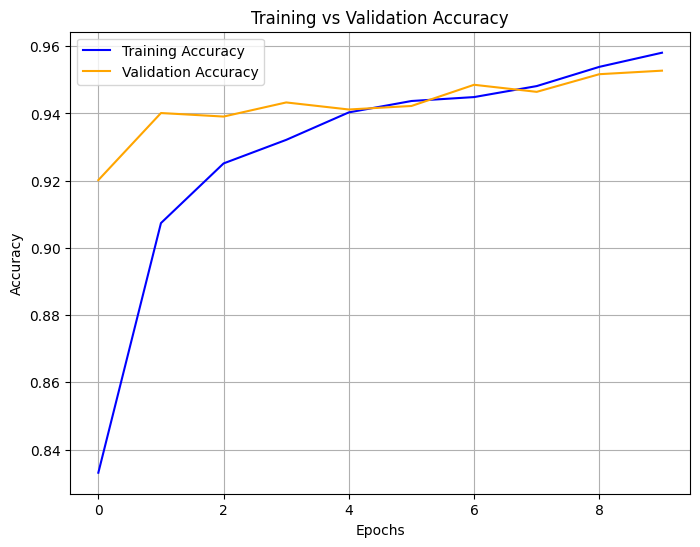

In [ ]:
import pickle
import matplotlib.pyplot as plt

# Load training history
with open("train_history.pkl", "rb") as f:
    history = pickle.load(f)

# Extract accuracy and validation accuracy
train_acc = history['accuracy']
val_acc = history['val_accuracy']

# Plot Accuracy Graph
plt.figure(figsize=(8, 6))
plt.plot(train_acc, label="Training Accuracy", color="blue")
plt.plot(val_acc, label="Validation Accuracy", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()






In [6]:
import pickle
filename = 'model.pkl'
with open(filename, 'wb') as file:
    pickle.dump(model, file)


In [7]:
!git clone https://github.com/Vansh-0606/CNN-MLP-PDM


Cloning into 'CNN-MLP-PDM'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 72 (delta 34), reused 19 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 13.68 MiB | 20.05 MiB/s, done.
Resolving deltas: 100% (34/34), done.


In [ ]:
!mv /content/your_notebook.ipynb /content/your-repo/
